In [1]:
!git clone https://github.com/KaizokuOu56/movingMirror.git

Cloning into 'movingMirror'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 135 (delta 18), reused 25 (delta 9), pack-reused 93 (from 1)
Receiving objects: 100% (135/135), 171.38 MiB | 30.83 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [2]:
%cd movingMirror
!git status

/content/movingMirror
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import os

DATA_DIR = "/content/drive/MyDrive/movingMirror/models/heat_pde1d/data"
os.makedirs(DATA_DIR, exist_ok=True)

OUT_FILE = os.path.join(DATA_DIR, "heat1d_fno_data.npz")

In [5]:
def solve_heat_1d(u0, alpha, k, T_env, dx, dt, n_steps):
    """
    Explicit finite-difference solver for:
        ∂T/∂t = α ∂²T/∂x² − k (T − T_env)
    """
    u = u0.copy()
    for _ in range(n_steps):
        u_xx = (np.roll(u, -1) - 2*u + np.roll(u, 1)) / dx**2
        u += dt * (alpha * u_xx - k * (u - T_env))
    return u


In [6]:
def random_initial_condition(x):
    """
    Smooth random function via Fourier modes
    """
    u = np.zeros_like(x)
    for k in range(1, 6):
        amp = np.random.uniform(-1, 1)
        phase = np.random.uniform(0, 2*np.pi)
        u += amp * np.sin(2 * np.pi * k * x + phase)
    return u


In [7]:
# Dataset size
N_SAMPLES = 20_000
N_X = 200

# Spatial grid
x = np.linspace(0, 1, N_X)
dx = x[1] - x[0]

# Storage
u0_all = np.zeros((N_SAMPLES, N_X), dtype=np.float32)
uT_all = np.zeros((N_SAMPLES, N_X), dtype=np.float32)
params_all = np.zeros((N_SAMPLES, 3), dtype=np.float32)

for i in range(N_SAMPLES):
    # Random parameters
    alpha = np.random.uniform(1e-5, 1e-4)
    k = np.random.uniform(0.01, 0.1)
    T_env = np.random.uniform(15.0, 35.0)
    T_final = np.random.uniform(0.5, 2.0)

    # Initial condition
    u0 = random_initial_condition(x)

    # Stable time step
    dt = 0.25 * dx**2 / alpha
    n_steps = int(T_final / dt)

    # Solve PDE
    uT = solve_heat_1d(u0, alpha, k, T_env, dx, dt, n_steps)

    # Store
    u0_all[i] = u0
    uT_all[i] = uT
    params_all[i] = [alpha, k, T_env]

    if i % 2000 == 0:
        print(f"Generated {i}/{N_SAMPLES}")

print(f"Done son")


Generated 0/20000
Generated 2000/20000
Generated 4000/20000
Generated 6000/20000
Generated 8000/20000
Generated 10000/20000
Generated 12000/20000
Generated 14000/20000
Generated 16000/20000
Generated 18000/20000
Done son


In [8]:
np.savez_compressed(
    OUT_FILE,
    u0=u0_all,
    uT=uT_all,
    params=params_all,
    x=x
)

print(f"Saved dataset to: {OUT_FILE}")

Saved dataset to: /content/drive/MyDrive/movingMirror/models/heat_pde1d/data/heat1d_fno_data.npz


In [9]:
!pip install neuraloperator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 7.0 MB/s eta 0:00:00


In [10]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os

from neuralop.models import FNO

In [11]:
DATA_PATH = "/content/drive/MyDrive/movingMirror/models/heat_pde1d/data/heat1d_fno_data.npz"
CKPT_DIR  = "/content/drive/MyDrive/movingMirror/models/heat_pde1d/checkpoint"
os.makedirs(CKPT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
data = np.load(DATA_PATH)

u0 = data["u0"]        # (N, 200)
uT = data["uT"]        # (N, 200)
params = data["params"]  # (N, 3)
x = data["x"]          # (200,)

N = u0.shape[0]
perm = np.random.permutation(N)

n_train = int(0.8 * N)
n_val   = int(0.9 * N)

train_idx = perm[:n_train]
val_idx   = perm[n_train:n_val]
test_idx  = perm[n_val:]

In [13]:
class HeatFNODataset(Dataset):
    def __init__(self, u0, uT, params, x):
        self.u0 = torch.tensor(u0, dtype=torch.float32)
        self.uT = torch.tensor(uT, dtype=torch.float32)
        self.params = torch.tensor(params, dtype=torch.float32)
        self.x = torch.tensor(x, dtype=torch.float32)

    def __len__(self):
        return self.u0.shape[0]

    def __getitem__(self, idx):
        u0 = self.u0[idx]               # (200,)
        uT = self.uT[idx]               # (200,)
        p  = self.params[idx]           # (3,)

        x = self.x
        p_exp = p.unsqueeze(1).repeat(1, x.shape[0])  # (3, 200)

        inp = torch.cat([
            u0.unsqueeze(0),            # (1, 200)
            x.unsqueeze(0),             # (1, 200)
            p_exp                        # (3, 200)
        ], dim=0)                        # (5, 200)

        return inp, uT.unsqueeze(0)      # output: (1, 200)

In [14]:
train_ds = HeatFNODataset(u0[train_idx], uT[train_idx], params[train_idx], x)
val_ds   = HeatFNODataset(u0[val_idx],   uT[val_idx],   params[val_idx],   x)
test_ds  = HeatFNODataset(u0[test_idx],  uT[test_idx],  params[test_idx],  x)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

In [15]:
model = FNO(
    n_modes=(16,),        # Fourier modes
    hidden_channels=64,   # width
    in_channels=5,        # u0, x, alpha, k, T_env
    out_channels=1,       # uT
    n_layers=4
).to(DEVICE)

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [17]:
from tqdm.auto import tqdm

def train_epoch(loader, epoch):
    model.train()
    running_loss = 0.0

    pbar = tqdm(
        loader,
        desc=f"Train | Epoch {epoch}",
        leave=False,
        dynamic_ncols=True
    )

    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [18]:
def eval_epoch(loader, epoch):
    model.eval()
    running_loss = 0.0

    pbar = tqdm(
        loader,
        desc=f"Val   | Epoch {epoch}",
        leave=False,
        dynamic_ncols=True
    )

    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            loss = criterion(pred, y)

            running_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [19]:
EPOCHS = 30

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="Epochs")

for ep in epoch_bar:
    train_loss = train_epoch(train_loader, ep)
    val_loss   = eval_epoch(val_loader, ep)

    epoch_bar.set_postfix(
        train=f"{train_loss:.3e}",
        val=f"{val_loss:.3e}"
    )

    if ep % 10 == 0:
        torch.save(
            model.state_dict(),
            os.path.join(CKPT_DIR, f"fno_neuralop_epoch_{ep}.pt")
        )

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Train | Epoch 1:   0%|          | 0/500 [00:00<?, ?it/s]

Val   | Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Train | Epoch 2:   0%|          | 0/500 [00:00<?, ?it/s]

Val   | Epoch 2:   0%|          | 0/63 [00:00<?, ?it/s]

...

Val   | Epoch 28:   0%|          | 0/63 [00:00<?, ?it/s]

Train | Epoch 29:   0%|          | 0/500 [00:00<?, ?it/s]

Val   | Epoch 29:   0%|          | 0/63 [00:00<?, ?it/s]

Train | Epoch 30:   0%|          | 0/500 [00:00<?, ?it/s]

Val   | Epoch 30:   0%|          | 0/63 [00:00<?, ?it/s]

In [20]:
def test_model(loader):
    model.eval()
    errors = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            err = torch.norm(pred - y, dim=-1) / torch.norm(y, dim=-1)
            errors.append(err.mean().item())

    return np.mean(errors)

In [21]:
test_error = test_model(test_loader)
print(f"Relative L2 test error: {test_error:.4e}")

Relative L2 test error: 3.2645e-01


In [26]:
import matplotlib.pyplot as plt
import random

def plot_predictions(model, dataset, device, n_samples=3):
    model.eval()

    indices = random.sample(range(len(dataset)), n_samples)

    fig, axes = plt.subplots(
        n_samples, 1,
        figsize=(8, 3 * n_samples),
        sharex=True
    )

    if n_samples == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            x_inp, y_true = dataset[idx]

            x_inp = x_inp.unsqueeze(0).to(device)   # (1, C, N)
            y_true = y_true.squeeze(0).cpu().numpy()

            y_pred = model(x_inp).squeeze(0).squeeze(0).cpu().numpy()

            x_coord = x

            ax.plot(x_coord, y_true, label="Ground truth", linewidth=2)
            ax.plot(x_coord, y_pred, "--", label="FNO prediction", linewidth=2)

            rel_err = np.linalg.norm(y_pred - y_true) / np.linalg.norm(y_true)
            ax.set_title(f"Relative L2 error: {rel_err:.3e}")
            ax.legend()
            ax.grid(True)

    ax.set_xlabel("x")
    plt.tight_layout()
    plt.show()


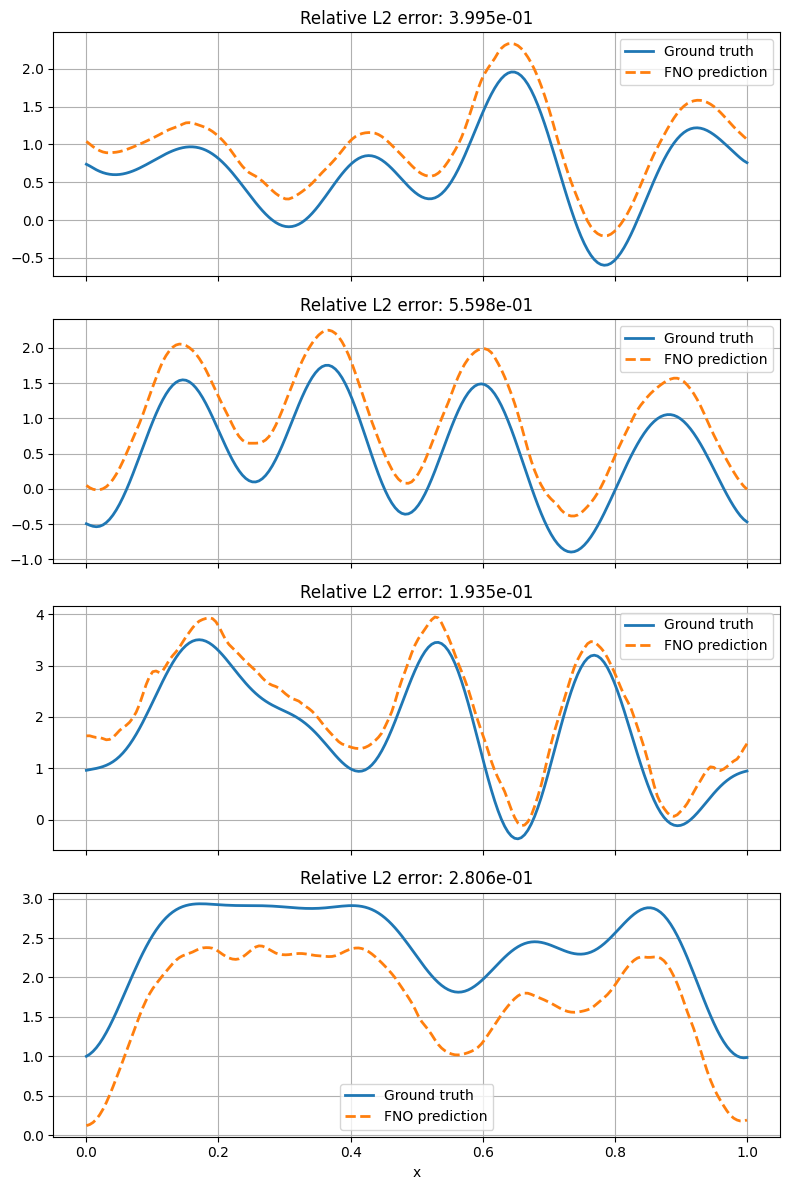

In [27]:
plot_predictions(
    model=model,
    dataset=test_ds,
    device=DEVICE,
    n_samples=4
)